## problem 1: solving the lorenz equations

In [11]:
from scipy.integrate import solve_ivp
import numpy as np


import matplotlib.pyplot as plt

In [5]:
sig = 10
rho = 28
beta = 8/3

x_0 = np.array([1.4324, 2.6837, 18.5043]).T

def func(t, input_var):
    x, y, z = input_var

    return (
        sig*(y - x),
        x*(rho - z) - y,
        x*y - beta * z
    )

In [35]:
t_span = (0, 10)
t_eval = np.linspace(t_span[0], t_span[1], 500)
t_delta = t_eval[1] - t_eval[0]

soln = solve_ivp(func, t_span, x_0, t_eval=t_eval)

In [29]:
x, y, z = soln.y
len(x)

500

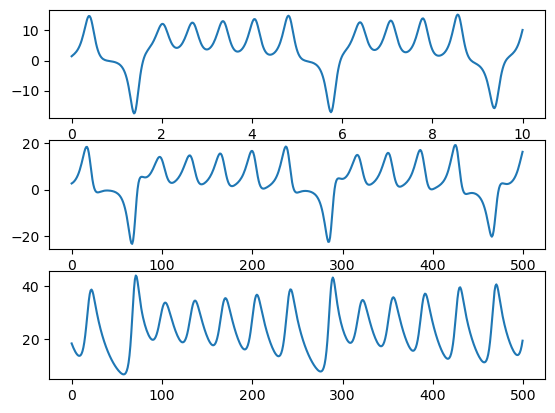

In [32]:
fig, axs = plt.subplots(3, 1)
axs = axs.flatten()

axs[0].plot(t_eval, x)
axs[1].plot(y)
axs[2].plot(z)

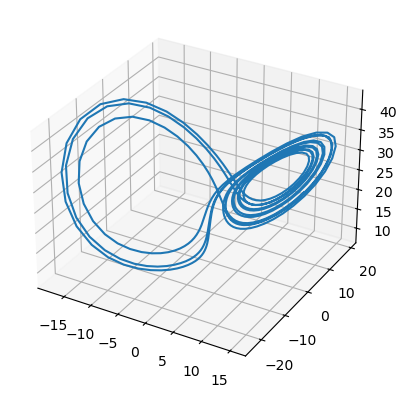

In [31]:
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})

ax.plot(x, y, z)

# problem 2: nearest-neighbour forecasting

In [49]:
from sklearn.model_selection import train_test_split

In [48]:
data = soln.y

t_fc = 1 # forecast time
n_fc = int(np.round(t_fc / t_delta)) # approx steps needed for forecast

tt_data = np.array([
    data[:, :-n_fc], data[:, n_fc:]
])

tt_data.shape

(2, 3, 450)

In [50]:
X_train, X_test, Y_train, Y_test = train_test_split(tt_data[0], tt_data[1], test_size=0.5)

In [51]:
X_train.shape

(1, 450)

# problem 3: metric entropy

In [53]:
from scipy.optimize import fsolve

mean = 0
sig_x = 1

def r(time):
    '''placeholder for func // probably pearson's corr coefficient?'''
    return time

def func(h, mean=mean, sig_x=sig_x, t_fc=t_fc):
    return np.log(mean / 2*sig_x) + 2*h*t_fc - np.log(1 - r(t_fc))

In [ ]:
root = fsolve(func, [1])

# Problem 4: introducing noise

# Problem 5: Computing the Lyapunov Spectrum

# Problem 6: Lyapunov Exponents and the Metric Entropy